## 1. Install required libraries

In [1]:
!pip install -q transformers faiss-cpu torch pillow kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 36.2 MB/s eta 0:00:00


## 2. Connect Kaggle account and download the dataset directly

In [ ]:
from google.colab import files
import os

uploaded = files.upload()

os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

print("\nDownloading the Egypt Landmarks dataset from Kaggle...")
!kaggle datasets download -d aymanmostafa11/eg-landmarks --unzip -p eg_landmarks_data

print("\nDownload complete")

Upload the kaggle.json file you downloaded from your Kaggle account settings:


Saving kaggle.json to kaggle.json

Dataset URL: https://www.kaggle.com/datasets/aymanmostafa11/eg-landmarks
License(s): CC0-1.0
100% 50.8M/50.8M [00:00<00:00, 93.1MB/s]


Download complete


## 3. Explore the dataset structure

In [3]:
def print_tree(path, prefix="", max_depth=3, depth=0, max_items=8):
    if depth > max_depth:
        return
    try:
        items = sorted(os.listdir(path))
    except NotADirectoryError:
        return
    for item in items[:max_items]:
        item_path = os.path.join(path, item)
        print(f"{prefix}{item}" + ("/" if os.path.isdir(item_path) else ""))
        if os.path.isdir(item_path):
            print_tree(item_path, prefix + "    ", max_depth, depth + 1, max_items)
    if len(items) > max_items:
        print(f"{prefix}... and {len(items) - max_items} more item(s)")

print("Dataset folder structure:\n")
print_tree("eg_landmarks_data")

Dataset folder structure:

gldv2_info.csv
images/
    6_October_Bridge/
        0.jpg
        1.jpg
        10.jpg
        11.jpg
        12.jpg
        13.jpg
        14.jpg
        2.jpg
        ... and 7 more item(s)
    Abdeen_Palace/
        0.jpg
        1.jpg
        10.jpg
        11.jpg
        12.jpg
        13.jpg
        14.jpg
        15.jpg
        ... and 9 more item(s)
    Abu_Ghurab/
        0.jpg
    Abu_Haggag_Mosque/
        0.jpg
        1.jpg
        10.jpg
        11.jpg
        12.jpg
        13.jpg
        14.jpg
        15.jpg
        ... and 29 more item(s)
    Abu_Qir_Bay/
        0.jpg
    Abu_el-Abbas_el-Mursi_Mosque/
        0.jpg
        1.jpg
        10.jpg
        11.jpg
        12.jpg
        13.jpg
        14.jpg
        15.jpg
        ... and 28 more item(s)
    Agiba_beach/
        0.jpg
        1.jpg
        10.jpg
        11.jpg
        12.jpg
        13.jpg
        14.jpg
        15.jpg
        ... and 67 more item(s)
    Aguilkia_Island/
      

## 4. Auto-detect place folders (robust to any nesting depth)

Instead of assuming one fixed folder depth (which breaks if the dataset has a train/test split or an extra wrapper folder), this scans the **entire** dataset tree and treats any folder that directly contains images as a "place", regardless of how deep it's nested. If a class name appears in more than one place (e.g. both under `train/` and `test/`), its images are simply merged — which is fine for building a retrieval index.

In [4]:
VALID_EXT = (".jpg", ".jpeg", ".png", ".webp")
DATASET_ROOT = "eg_landmarks_data"

def find_place_folders(root_dir):
    """
    Walk the whole dataset tree and return {place_name: [full_image_paths]}.
    Any folder that directly contains image files is treated as a place.
    """
    places = {}
    for dirpath, _dirnames, filenames in os.walk(root_dir):
        images = [f for f in filenames if f.lower().endswith(VALID_EXT)]
        if not images:
            continue
        place_name = os.path.basename(dirpath)
        places.setdefault(place_name, [])
        places[place_name].extend(os.path.join(dirpath, f) for f in images)
    return places

places = find_place_folders(DATASET_ROOT)

if not places:
    raise RuntimeError(
        "No images found. Check the folder tree printed above and adjust DATASET_ROOT if needed."
    )

print(f"Found {len(places)} place(s):")
for place, imgs in sorted(places.items()):
    print(f"  - {place}: {len(imgs)} images")

Found 279 place(s):
  - 6_October_Bridge: 15 images
  - Abdeen_Palace: 17 images
  - Abu_Ghurab: 1 images
  - Abu_Haggag_Mosque: 37 images
  - Abu_Qir_Bay: 1 images
  - Abu_el-Abbas_el-Mursi_Mosque: 36 images
  - Agiba_beach: 75 images
  - Aguilkia_Island: 5 images
  - Ahmed_Shawki_Museum: 4 images
  - Al-Aqmar_Mosque: 25 images
  - Al-Ashraf_Mosque: 17 images
  - Al-Azhar_Park_(Cairo): 50 images
  - Al-Fath_Mosque: 3 images
  - Al-Ghuri_Complex: 39 images
  - Al-Jawhara_Palace_museum: 4 images
  - Al-Manyal_Palace_Museum: 22 images
  - Al-Nur_Mosque: 9 images
  - Al-Qurn: 13 images
  - Al-Rifa'i_Mosque: 5 images
  - Al-Salih_Tala'i_Mosque: 15 images
  - Al-Sayeda_Nafeesah_Mosque: 6 images
  - Al-Sayeda_Zainab_Mosque: 1 images
  - Al-Shate'e_Mosque: 17 images
  - Al_Fattah_Al_Alim_Mosque_(Cairo): 1 images
  - Alexandria_National_Museum: 3 images
  - Alexandria_Opera_House: 89 images
  - Alexandria_Port: 4 images
  - Alexandria_Stadium: 3 images
  - Alexandria_Zoo: 13 images
  - Amada: 

## 5. Load the CLIP model (free, from Hugging Face)

In [5]:
import torch
import numpy as np
from PIL import Image
from transformers import CLIPModel, CLIPProcessor

MODEL_NAME = "openai/clip-vit-base-patch32"

device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Using device: {device}")

model = CLIPModel.from_pretrained(MODEL_NAME).to(device)
processor = CLIPProcessor.from_pretrained(MODEL_NAME)

model.eval()


def get_image_embedding(image_path):
    """Convert an image into a normalized CLIP embedding."""

    image = Image.open(image_path).convert("RGB")

    inputs = processor(
        images=image,
        return_tensors="pt"
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        vision_outputs = model.vision_model(**inputs)

        pooled_output = vision_outputs.pooler_output

        features = model.visual_projection(pooled_output)

        features = features / torch.norm(
            features,
            p=2,
            dim=-1,
            keepdim=True
        )

    return features.cpu().numpy().astype("float32").flatten()


print("Model ready")

Using device: cuda


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Model ready


In [6]:
test_place = sorted(places.keys())[0]
test_image = places[test_place][0]

embedding = get_image_embedding(test_image)

print("Place:", test_place)
print("Image:", test_image)
print("Embedding shape:", embedding.shape)
print("Embedding dtype:", embedding.dtype)
print("Embedding norm:", np.linalg.norm(embedding))

Place: 6_October_Bridge
Image: eg_landmarks_data/images/6_October_Bridge/12.jpg
Embedding shape: (512,)
Embedding dtype: float32
Embedding norm: 1.0


In [7]:
import faiss
import json

MAX_IMAGES_PER_PLACE = 30

embeddings = []
mapping = {}
position = 0

for place_name, image_paths in sorted(places.items()):

    if MAX_IMAGES_PER_PLACE:
        image_paths = image_paths[:MAX_IMAGES_PER_PLACE]

    print(f"Processing '{place_name}' ({len(image_paths)} images)...")

    for image_path in image_paths:

        try:
            emb = get_image_embedding(image_path)

            embeddings.append(emb)

            mapping[str(position)] = {
                "place": place_name,
                "image": os.path.basename(image_path)
            }

            position += 1

        except Exception as e:
            print(f"  Error on {image_path}: {e}")


if not embeddings:
    raise RuntimeError(
        "No embeddings were generated. Check get_image_embedding()."
    )


embeddings_matrix = np.vstack(embeddings).astype("float32")

dimension = embeddings_matrix.shape[1]

index = faiss.IndexFlatIP(dimension)

index.add(embeddings_matrix)

faiss.write_index(index, "places_index.faiss")

with open("places_mapping.json", "w", encoding="utf-8") as f:
    json.dump(mapping, f, ensure_ascii=False, indent=2)

print(
    f"\nIndex built: {len(embeddings)} images indexed "
    f"across {len(places)} places"
)

print("Embedding dimension:", dimension)

Processing '6_October_Bridge' (15 images)...
Processing 'Abdeen_Palace' (17 images)...
Processing 'Abu_Ghurab' (1 images)...
Processing 'Abu_Haggag_Mosque' (30 images)...
Processing 'Abu_Qir_Bay' (1 images)...
Processing 'Abu_el-Abbas_el-Mursi_Mosque' (30 images)...
Processing 'Agiba_beach' (30 images)...
Processing 'Aguilkia_Island' (5 images)...
Processing 'Ahmed_Shawki_Museum' (4 images)...
Processing 'Al-Aqmar_Mosque' (25 images)...
Processing 'Al-Ashraf_Mosque' (17 images)...
Processing 'Al-Azhar_Park_(Cairo)' (30 images)...
Processing 'Al-Fath_Mosque' (3 images)...
Processing 'Al-Ghuri_Complex' (30 images)...
Processing 'Al-Jawhara_Palace_museum' (4 images)...
Processing 'Al-Manyal_Palace_Museum' (22 images)...
Processing 'Al-Nur_Mosque' (9 images)...
Processing 'Al-Qurn' (13 images)...
Processing 'Al-Rifa'i_Mosque' (5 images)...
Processing 'Al-Salih_Tala'i_Mosque' (15 images)...
Processing 'Al-Sayeda_Nafeesah_Mosque' (6 images)...
Processing 'Al-Sayeda_Zainab_Mosque' (1 images).

## 6. Build the similarity index (FAISS)


## 7. Test with a new photo

Upload a test photo:


Saving 1.jpg to 1.jpg


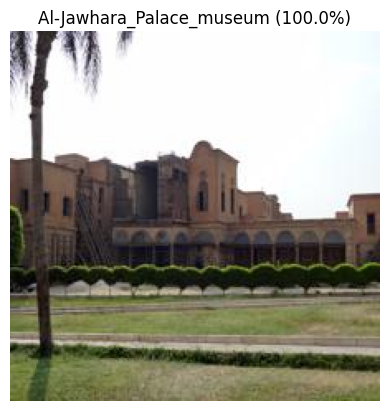

Similarity score: 100.00%
Result: Al-Jawhara_Palace_museum

All candidate matches:
  Al-Jawhara_Palace_museum: 100.00%
  Al-Manyal_Palace_Museum: 83.38%
  Cairo_Citadel: 83.12%
  Al-Azhar_Park_(Cairo): 83.11%
  Montaza_Palace: 81.99%


In [8]:
import matplotlib.pyplot as plt

CONFIDENCE_THRESHOLD = 0.75
TOP_K = 5

print("Upload a test photo:")
test_upload = files.upload()
test_image_path = list(test_upload.keys())[0]

query_embedding = get_image_embedding(test_image_path).reshape(1, -1)
scores, indices = index.search(query_embedding, TOP_K)

place_scores = {}
for score, idx in zip(scores[0], indices[0]):
    if idx == -1:
        continue
    place = mapping[str(idx)]["place"]
    place_scores[place] = max(place_scores.get(place, 0), float(score))

best_place = max(place_scores, key=place_scores.get)
best_score = place_scores[best_place]

img = Image.open(test_image_path)
plt.imshow(img)
plt.axis('off')
plt.title(f"{best_place} ({best_score:.1%})" if best_score >= CONFIDENCE_THRESHOLD else "Not confident enough")
plt.show()

print(f"Similarity score: {best_score:.2%}")
if best_score >= CONFIDENCE_THRESHOLD:
    print(f"Result: {best_place}")
else:
    print("Not confident about this place — consider adding more reference images.")

print("\nAll candidate matches:")
for place, score in sorted(place_scores.items(), key=lambda x: -x[1]):
    print(f"  {place}: {score:.2%}")